# In-Depth: Manifold Learning

## Manifold Learning: HELLO

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns; sns.set_theme()
import numpy as np
import os

In [187]:
# Directory to save the extracted TIFF file
output_dir = os.getcwd()
while 'assets' not in os.listdir(output_dir):
    output_dir = os.path.dirname(output_dir)

output_dir = os.path.join(output_dir, 'assets')
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, 'hello.png')

fig, ax = plt.subplots(figsize=(4,1))
ax.axis('off')
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
ax.text(0.5,0.4,"HELLO", va='center', ha='center', weight='bold', size=85)
fig.savefig(file_path)
plt.close(fig)

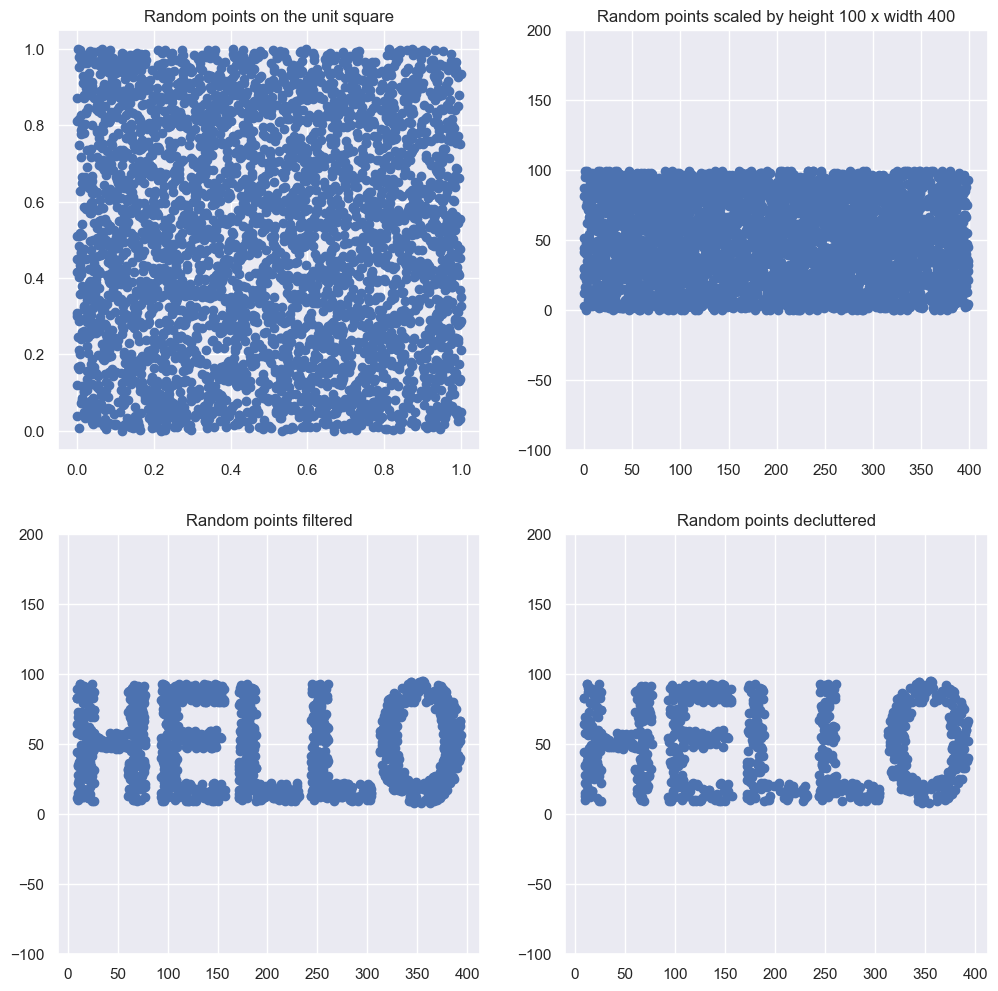

In [199]:
# 1. Read image data
# > image will be read from top to bottom so we flip it so that it starts from bottom to top when plotted on the xy-plane
# > The image shape is (400,100,4) where the third dimension is the image channel. Since the image is just black and white, all channels
#   contain essentially the same information. Thus, keeping channel 0 is enough.
# > The first dimension is image height while the second is image width. In order to properly plot on the xy-plane, we have to transpose
#   That way, x = width and y = height

data = imread(file_path)[::-1, :, 0].T

fig, axs = plt.subplots(2,2,figsize=(12,12))

# 2. Generate random points
# Generate random points on the square [0,1] x [0,1]
# Here, we'll generate 4000 random points
rng = np.random.RandomState(42)
X = rng.rand(4 * 1000, 2)
axs[0,0].scatter(X[:,0], X[:,1])
axs[0,0].set_title('Random points on the unit square')

# 3. Scale the random points so that it covers the image data
# Image data is 100 pixels x 400 pixels. we want the random points to cover this rectangle
# So, we scale the first coordinate by 200 and the second coordinate by 400.
X_scaled = (X * data.shape).astype(int)
axs[0,1].scatter(X_scaled[:,0],X_scaled[:,1])
axs[0,1].set_title('Random points scaled by height 100 x width 400')
axs[0,1].set_ylim(-100,200)

# 4. Filter out points that are not covering the image data
# Using boolean masking!
# points (j,i) that cover the image satisfy data[i,j] < 1
i,j = X_scaled.T
mask = (data[i,j] < 1)
X_filtered = X_scaled[mask]
axs[1,0].scatter(X_filtered[:,0], X_filtered[:,1])
axs[1,0].set_ylim(-100,200)
axs[1,0].set_title('Random points filtered')

# 5. Remove some points to declutter hehe.. keep 1000 points
X_filtered = X_filtered[:1000]
axs[1,1].scatter(X_filtered[:,0], X_filtered[:,1])
axs[1,1].set_ylim(-100,200)
axs[1,1].set_title('Random points decluttered');

# 6. Sort x-coordinates
X_filtered = X_filtered[np.argsort(X_filtered[:,0])]

With the above experimentation, create a function that does the exact same thing

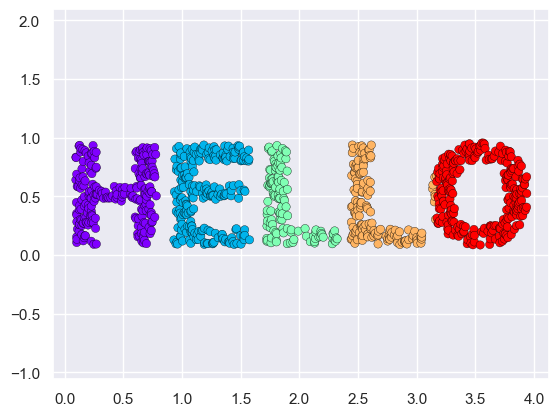

In [232]:
def make_word(word, N=1000, rseed=42):
    '''
    word: str; word to create random points on
    N: number of random points
    rseed: random seed

    returns: Numpy array of shape (n_samples, 2) where the first column contains first coordinates of the points
    and second column contains the second coordinates of the points.
    '''
    output_dir = os.getcwd()
    while 'assets' not in os.listdir(output_dir):
        output_dir = os.path.dirname(output_dir)
    
    output_dir = os.path.join(output_dir, 'assets')
    os.makedirs(output_dir, exist_ok=True)
    
    file_path = os.path.join(output_dir, f'{word}.png')
    
    fig, ax = plt.subplots(figsize=(4,1))
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.text(0.5,0.4,word, va='center', ha='center', weight='bold', size=85)
    fig.savefig(file_path)
    plt.close(fig)

    data = imread(file_path)[::-1, :, 0].T
    rng = np.random.RandomState(rseed)
    X = rng.rand(4 * N, 2)
    i,j = (X * data.shape).astype(int).T
    mask = (data[i,j] < 1)
    X = X[mask]
    X[:,0] *= data.shape[0] / data.shape[1]
    X = X[:1000]

    return X[np.argsort(X[:,0])]

X = make_word('HELLO')
colorize = dict(c=X[:,0], cmap=plt.get_cmap('rainbow', 5))
plt.scatter(X[:,0], X[:,1], ec='black', linewidths=0.25, **colorize)
plt.axis('equal');

## Multidimensional Scaling (MDS)

Looking at a data like this, it seems like it does not matter which coordinate system we use to plot the data. We can rotate it, shrink, or translate the data, and the word 'HELLO' will still be apparent.

For instance, we can rotate and translate the data, and the data will stay the same, just rotated and translated.

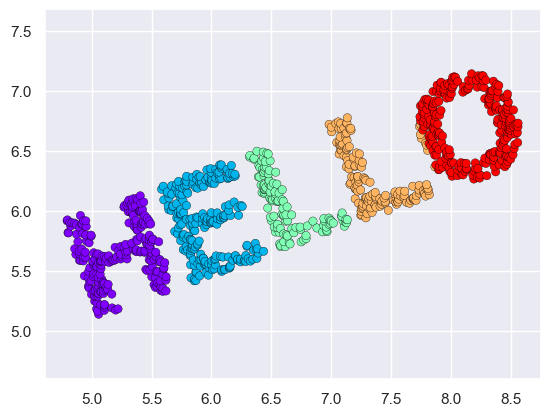

In [236]:
def rotate(X, angle):
    theta = np.deg2rad(angle)
    R = [[np.cos(theta), np.sin(theta)],
        [-np.sin(theta), np.cos(theta)]]
    return np.dot(X, R)

Xr = rotate(X, 20) + 5 # Rotate X 20 degrees counterclockwise and translate by 5
plt.scatter(Xr[:,0], Xr[:,1], ec='black', linewidths=0.25, **colorize)
plt.axis('equal');

What is fundamental about the data that describes the relationship between the points is the distance between the points -- the geometry of the data! With that, we can ditch coordinate systems (it doesn't matter which one we choose anyway) and find a representation of the data that is based on distances.

For the data with 1000 samples, we can create a matrix of distances between each pair of points. The result is a 1000 x 1000 shaped matrix where entry $i,j$ is the distance between point $i$ and point $j$.

In [233]:
from sklearn.metrics import pairwise_distances
D = pairwise_distances(X)
D.shape

(1000, 1000)

We can visualize the distance matrix as follows.

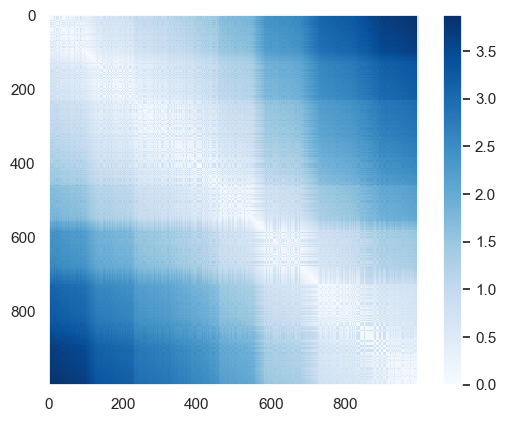

In [237]:
plt.imshow(D, zorder=2, cmap='Blues', interpolation='nearest')
plt.colorbar();

We can even create a pair-wise distance matrix for the rotated data and verify that it will be equal to the original.

In [244]:
Dr = pairwise_distances(Xr)
np.allclose(D,Dr)

True

The pairwise distances matrix is a representation of the data that is invariant under rotation, scaling, and translation. However, the word 'HELLO' is not anymore visible in the visualization of the distance matrix.

Furthermore, transforming from the distance matrix to a coordinate system is difficult.

This is where the **multidimensional scaling algorithm** comes to play: From the pairwise distances representation of the data, the multidimensional scaling algorithm attempts to recover a $D$-dimensional coordinate representation of the data.

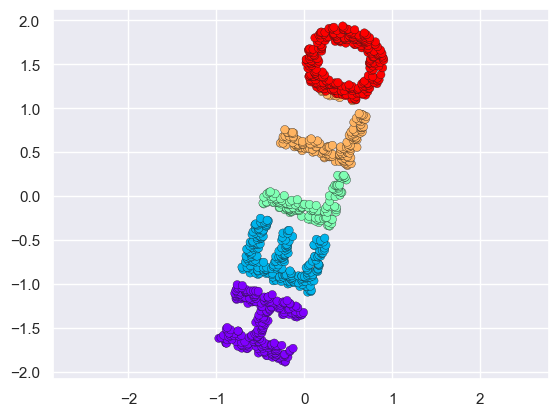

In [248]:
from sklearn.manifold import MDS
model = MDS(n_components = 2, metric='precomputed', random_state=1, init='random')
out = model.fit_transform(D)
plt.scatter(out[:,0], out[:,1], ec='k', linewidths=0.25, **colorize)
plt.axis('equal');

## MDS as Manifold Learning

For a given data that is embedded on high-dimensional space, a manifold learning estimator seeks a lower-dimensional representation of the data that preserves certain relationships within the data. For the case of MDS, the preserved relationship is distance.

Thus, manifold learning is useful for visualizing low-dimensional manifolds embedded on high-dimensional space. For instance, consider the 'HELLO' data earlier as a 2-dimensional manifold embedded on 3-dimensional space.

In [253]:
# Code copied from boook ... not much time to study the code... We'll come back to this later...
# Basically, what it does is to project 2d data randomly on 3d space with some rotations and translations...
def random_projection(X, dimension=3, rseed=42):
    assert dimension >= X.shape[1]
    rng = np.random.RandomState(rseed)
    C = rng.randn(dimension, dimension)
    e, V = np.linalg.eigh(np.dot(C, C.T))
    return np.dot(X, V[:X.shape[1]])
Xp = random_projection(X, 3)
Xp.shape

(1000, 3)

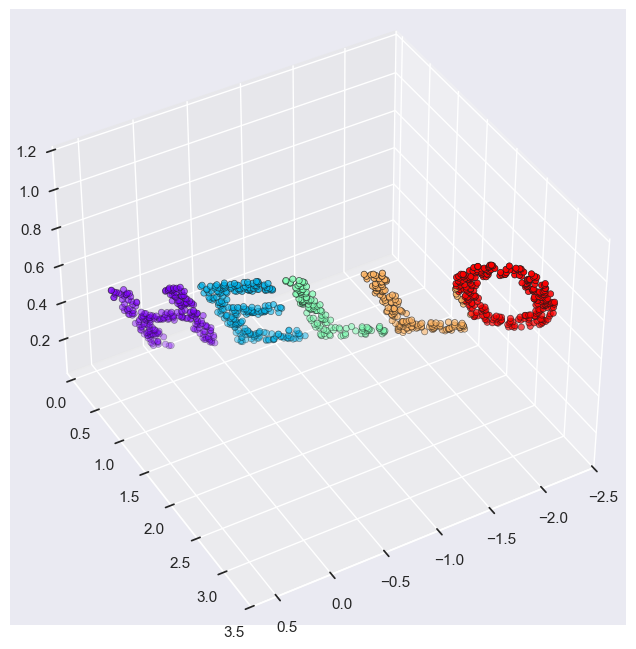

In [295]:
from mpl_toolkits import mplot3d
fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
ax.scatter3D(Xp[:, 0], Xp[:, 1], Xp[:, 2], ec='k', linewidths=0.5, **colorize);
ax.view_init(azim=60, elev=40)

Once again, the coordinate system does not matter and the pairwise distances better describe the relationship of the points in the data.

Furthermore, while the data is on 3-dimensional space, it is clearly an embedded 2-dimensional manifold (like a sheet of paper -- you can bend it or hold it up in the air but the paper itself can be laid flat on 2-dimensional space.)

We can use the MDS estimator to create the pairwise distance matrix and find the optimal 2D coordinate representation for the distance matrix.

In [297]:
model = MDS(n_components=2, init='random', random_state=1)
Xp_transform = model.fit_transform(Xp)
Xp_transform.shape

(1000, 2)

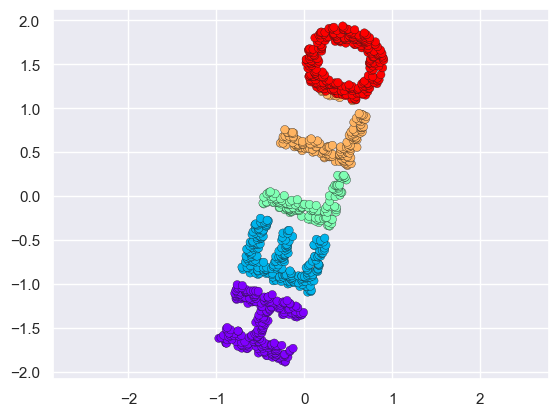

In [298]:
plt.scatter(Xp_transform[:,0], Xp_transform[:,1], ec='k', linewidths=0.25, **colorize)
plt.axis('equal');

## Nonlinear Embeddings: Where MDS Fails

MDS fails when the embeddeding is nonlinear.

The 3D example earlier shows a linear embedding: the data is on some rotated and translated plane in 3-dimensional space. A nonlinear embedding would like the following.

In [299]:
# Again transformer copied from the book... will come back later...
def make_hello_s_curve(X):
    t = (X[:, 0] - 2) * 0.75 * np.pi
    x = np.sin(t)
    y = X[:, 1]
    z = np.sign(t) * (np.cos(t) - 1)
    return np.vstack((x, y, z)).T

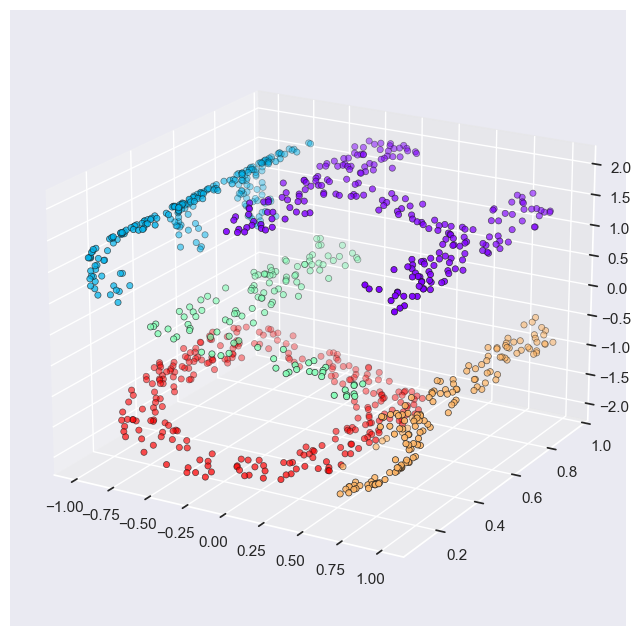

In [319]:
Xs = make_hello_s_curve(X)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
ax.scatter3D(Xs[:, 0], Xs[:, 1], Xs[:, 2], ec='k', linewidths=0.5, **colorize);
ax.view_init(azim=300, elev=20)

In this embedding, the data containing points on the word 'HELLO' is wrapped to an 'S' shape, similar to a wrapped paper so that it looks like an 'S'.

MDS will not be able to unwrap the 'S' shape in this embedding and if we try it out, MDS will not be able to recover the fundamental relationship in the data.

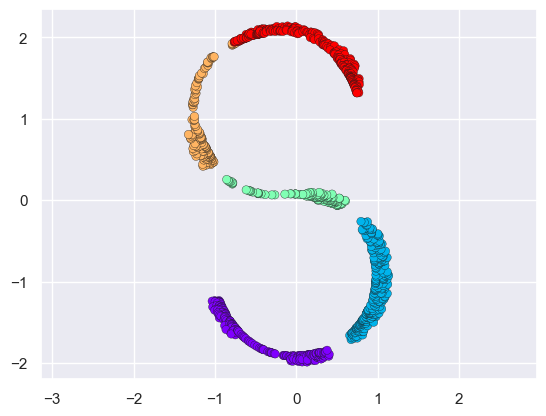

In [321]:
model = MDS(n_components=2, init='random', random_state=1)
Xs_transformed = model.fit_transform(Xs)

plt.scatter(Xs_transformed[:,0], Xs_transformed[:,1], ec='k', linewidths=0.25, **colorize)
plt.axis('equal');

## Nonlinear Manifolds: Locally Linear Embedding

A wayforward to this problem is to consider **Locally Linear Embedding**.

Nonlinear manifolds are locally linear. In other words, for each point on a nonlinear manifold, there exists a linear embedding (a plane, basically) that approximates a neighborhood of the point.

What MDS does is it seeks a low-dimensional embedding that preserves distances between *all* pairs of points.

**Locally linear embedding** is another manifold learning estimator, but instead of preserving all distances, it preserves distances of nearby points (those nearby points can be approximated by a linear embedding). This way, it is able to unwrap the nonlinearity of the embedding.

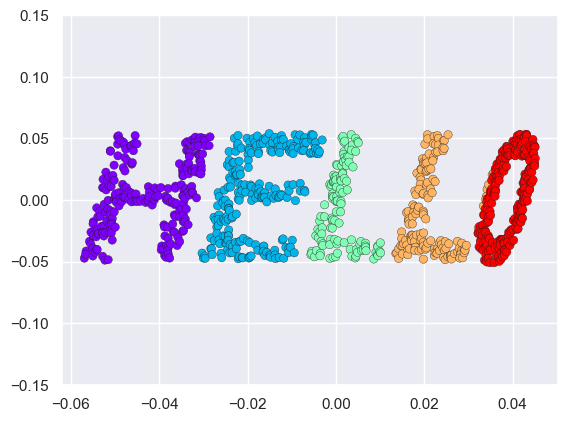

In [326]:
from sklearn.manifold import LocallyLinearEmbedding
model = LocallyLinearEmbedding(n_neighbors=100, n_components=2, method='modified', eigen_solver='dense')
X_lle = model.fit_transform(Xs)

plt.scatter(X_lle[:,0], X_lle[:,1], ec='k', linewidths=0.25, **colorize)
plt.ylim(-0.15,0.15);

## Challenges of Manifold Learning

Manifold learning is rarely used for anything other than visualization.

Some challenges include:
- No good framework for handling missing data
- Sensitive to noise: presence of noise can drastically change the embedding.
- The embedding result is highly dependent on the number of neighbors chosen (`n_neighbors` hyperparameter in LLE) and there is no quantitative way to choose an optimal number of neighbors.
- The optimal dimension of the embedding is difficult to determine (the `n_components` hyperparameter); unlike in PCA where we can plot the cumulative variance ratio.
- Computationally expensive.

One clear advantage of manifold learning over PCA is that it is able to preserve nonlinear relationships. It is recommended to use it only after exploring data with PCA.

### Recommended Algorithms (based on author's experience)
- For toy problems, MDS and LLE perform well.
- For real-world datasets, **Isomap** generally leads to meaningful embeddings.
- For highly clustered data, **t-distributed stochastic neighborhood embedding (t-SNE)** works well, but is slow.

## Example: Isomap on Faces

Objective: Draw some insights on the LFW images data. Try to visualize the high-dimensional pixel features and suggest next steps.

In [327]:
from sklearn.datasets import fetch_lfw_people
path = '~/IBM-Data-Science-Specialization/Course-9_Machine-Learning/data/Labeled_Faces_in_the_Wild'
faces = fetch_lfw_people(data_home=path,min_faces_per_person=30)
print(faces.target_names)
print(faces.images.shape)

['Alejandro Toledo' 'Alvaro Uribe' 'Andre Agassi' 'Ariel Sharon'
 'Arnold Schwarzenegger' 'Colin Powell' 'David Beckham' 'Donald Rumsfeld'
 'George W Bush' 'Gerhard Schroeder' 'Gloria Macapagal Arroyo'
 'Guillermo Coria' 'Hans Blix' 'Hugo Chavez' 'Jacques Chirac'
 'Jean Chretien' 'Jennifer Capriati' 'John Ashcroft' 'John Negroponte'
 'Junichiro Koizumi' 'Kofi Annan' 'Laura Bush' 'Lleyton Hewitt'
 'Luiz Inacio Lula da Silva' 'Megawati Sukarnoputri' 'Nestor Kirchner'
 'Recep Tayyip Erdogan' 'Roh Moo-hyun' 'Serena Williams'
 'Silvio Berlusconi' 'Tom Ridge' 'Tony Blair' 'Vicente Fox'
 'Vladimir Putin']
(2370, 62, 47)


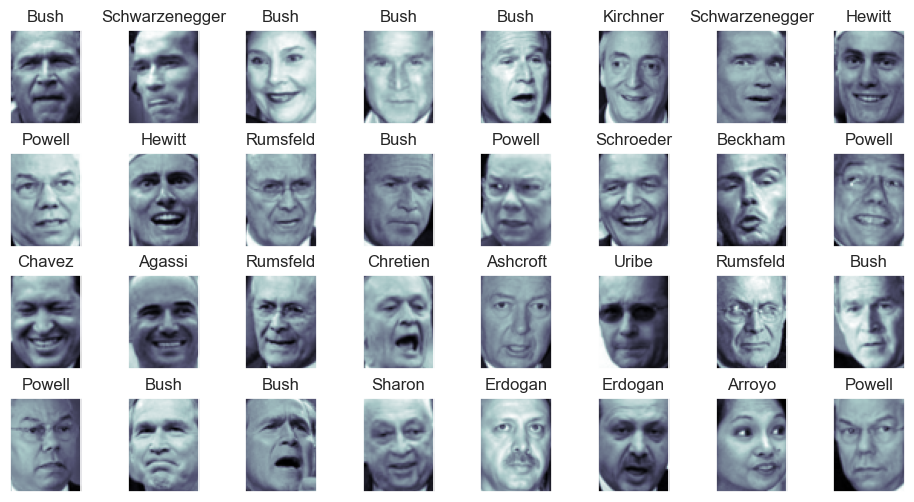

In [341]:
fig, axs = plt.subplots(4,8,figsize=(12,6),
                       subplot_kw = dict(xticks=[], yticks=[]),
                       gridspec_kw = dict(hspace=0.3, wspace=0.1))

for i, ax in enumerate(axs.flat):
    ax.imshow(faces.images[i], cmap='bone')
    ax.set_title(faces.target_names[faces.target[i]].split(' ')[-1])
    
plt.show()

In [343]:
X = faces.data
X.shape

(2370, 2914)

In [349]:
from sklearn.decomposition import PCA
pca_model = PCA(n_components=500).fit(X)
pca_model

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",500
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

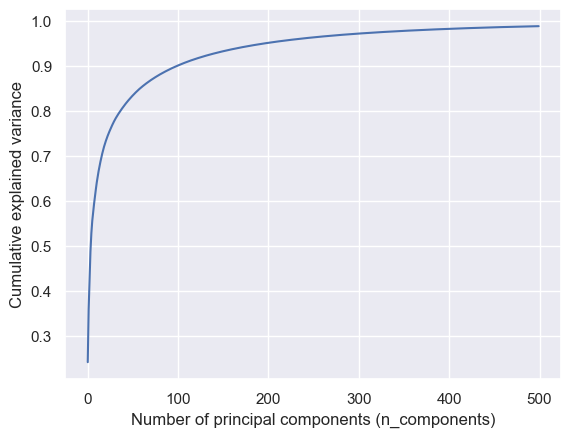

In [350]:
plt.plot(np.cumsum(pca_model.explained_variance_ratio_))
plt.xlabel('Number of principal components (n_components)')
plt.ylabel('Cumulative explained variance')
plt.show()

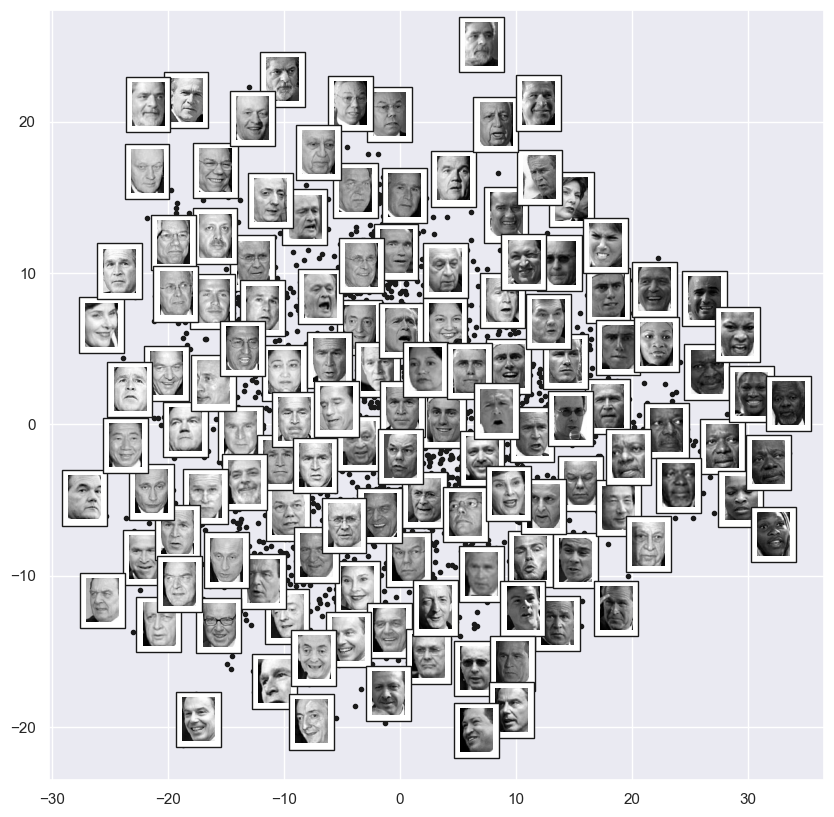

In [377]:
from sklearn.manifold import Isomap
from matplotlib import offsetbox

def plot_components(data, model, images=None, ax=None, thumb_frac=0.05, cmap='gray'):
    ax = ax or plt.gca()

    proj = model.fit_transform(X)
    ax.plot(proj[:,0], proj[:,1], '.k')

    if images is not None:
        min_dist_2 = (thumb_frac * max(proj.max(0) - proj.min(0))) ** 2
        shown_images = np.array([2 * proj.max(0)])
        for i in range(data.shape[0]):
            dist = np.sum((proj[i] - shown_images) ** 2, 1)
            if np.min(dist) < min_dist_2:
                continue
            shown_images = np.vstack([shown_images, proj[i]])
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(images[i], cmap=cmap, zoom=0.5), proj[i]
            )
            ax.add_artist(imagebox)

fig, ax = plt.subplots(figsize=(10,10))
plot_components(faces.data, model=Isomap(n_components=2), images=faces.images)

Based on this visualization, we can draw the following insights about the result of the Isomap transformation:
- The first dimension of the embedded manifold captures the lightness and darkness of the image
- The second dimension captures the orientation of face.

So, images with the same shade and facial orientation are within close neighborhoods of each other.

## Example: Visualizing Structure in Digits

In [392]:
from sklearn.datasets import fetch_openml
path = '~/IBM-Data-Science-Specialization/Course-9_Machine-Learning/data/MNIST_784'
mnist = fetch_openml('mnist_784', data_home=path)
X = mnist.data.to_numpy()
X.shape

(70000, 784)

In [380]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

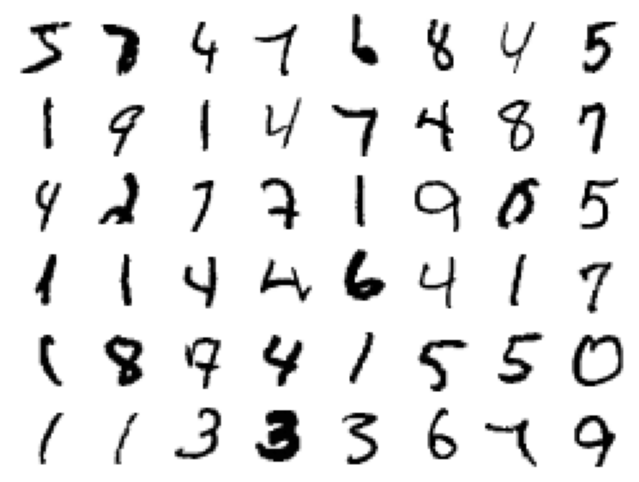

In [397]:
fig, axs = plt.subplots(6,8,figsize=(8,6),
                       subplot_kw = dict(xticks=[], yticks=[]),
                       gridspec_kw = dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axs.flat):
    ax.imshow(X[1400 * i].reshape(28,28), cmap='gray_r')

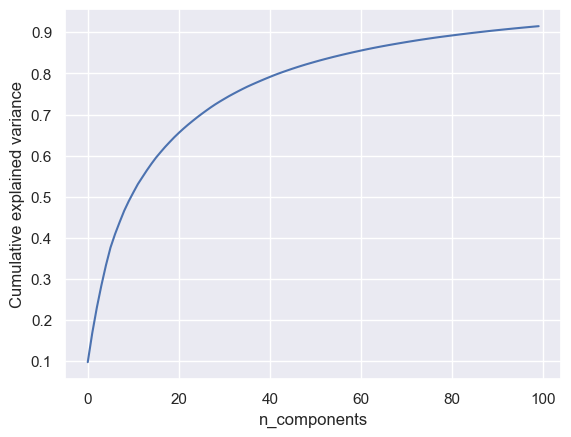

In [412]:
pca = PCA(n_components=100).fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('n_components')
plt.ylabel('Cumulative explained variance');

Generate a random sample of size 3000 from the dataset, since 70000 samples is too large to process, and manifold learning algorithms has relatively poor scaling

In [430]:
idx = np.random.choice(np.arange(70000), size=10000, replace=False)

In [432]:
isomap_proj = Isomap(n_components=2).fit_transform(X[idx])

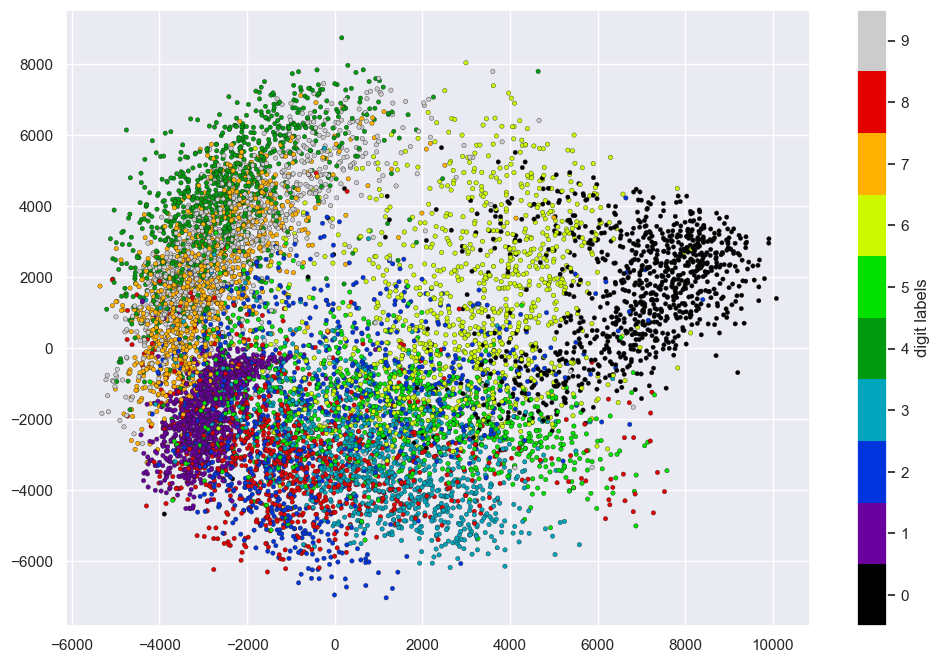

In [435]:
fig = plt.figure(figsize=(12,8))
plt.scatter(isomap_proj[:,0], isomap_proj[:,1], c=mnist.target.to_numpy().astype(int)[idx], 
            cmap=plt.get_cmap('nipy_spectral', 10),
           ec='k', linewidths=0.25, s=10)

plt.colorbar(label='digit labels', ticks=range(10))
plt.clim(-0.5,9.5)

Since the data is highly clustered, t-SNE may be a better algorithm than Isomap.

In [440]:
from sklearn.manifold import TSNE

tsne_proj = TSNE(n_components=2).fit_transform(X[idx])

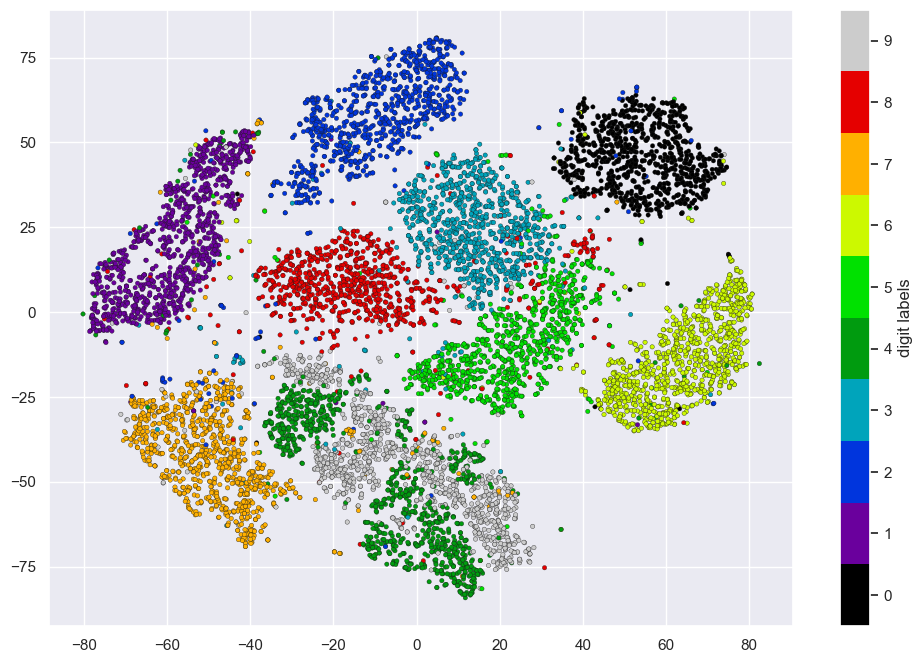

In [443]:
fig = plt.figure(figsize=(12,8))
plt.scatter(tsne_proj[:,0], tsne_proj[:,1], c=mnist.target.to_numpy().astype(int)[idx], 
            cmap=plt.get_cmap('nipy_spectral', 10),
           ec='k', linewidths=0.25, s=10)

plt.colorbar(label='digit labels', ticks=range(10))
plt.clim(-0.5,9.5)

That is awesome. Even without knowledge of the labels, the TSNE algorithm was able to find a clear separation of the classes.

## Digression: Numpy Comparisons, Masks, and Boolean Logic
Plotting random points on the image requires use of masking, so I figured to do some exercises first on some numpy comparisons, masks, and boolean logic.

**Boolean masking** comes up when you want to extract, modify, count, or otherwise manipulate values in an array based on some criterion.

### Example: Counting Rainy Days

In [22]:
import pandas as pd

rainfall = pd.read_csv('~/IBM-Data-Science-Specialization/Course-9_Machine-Learning/data/seattleWeather_1948-2017.csv')
rainfall.dtypes

DATE        str
PRCP    float64
TMAX      int64
TMIN      int64
RAIN     object
dtype: object

In [23]:
rainfall['DATE'] = pd.to_datetime(rainfall.DATE, format='ISO8601')

In [25]:
rainfall.dtypes

DATE    datetime64[us]
PRCP           float64
TMAX             int64
TMIN             int64
RAIN            object
dtype: object

In [27]:
rainfall.set_index('DATE', inplace=True)

In [29]:
rainfall.head()

,PRCP,TMAX,TMIN,RAIN
DATE,,,,
1948-01-01,0.47,51,42,True
1948-01-02,0.59,45,36,True
1948-01-03,0.42,45,35,True
1948-01-04,0.31,45,34,True
1948-01-05,0.17,45,32,True


In [36]:
rainfall_2014 = rainfall.loc['2014','PRCP'].values

In [60]:
inches = rainfall_2014
inches.shape

(365,)

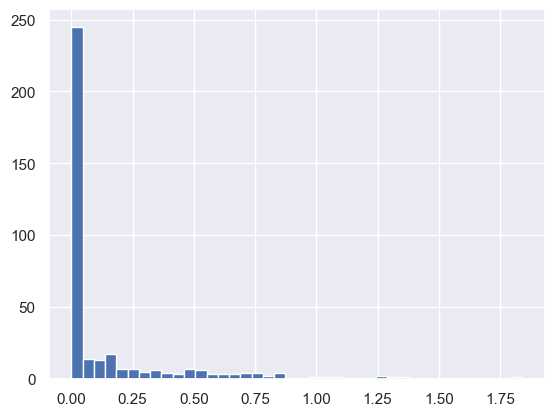

In [61]:
plt.hist(inches, 40);

So, it was mostly sunny in Seattle. But we'd also like to study the rainy days and might want some answers to the following questions:
- How many days were there with no rain?
- How many rainy days were there in 2014?
- How many days were there with more than 0.5 inches of rainfall?
- How many days were there with less than 1.0 inches of rainfall?
- What is the average precipitation?
- How many days were there with half an inch of rain?

### Comparison Operators as ufuncs

We can apply element-wise comparisons in numpy in the same way we do element-wise arithmetic operations with ufuncs.

| Operator | Equivalent ufunc |
| --- | --- |
| `==` | `np.equal` |
| `!=` | `np.not_equal` |
| `<` | `np.less` |
| `<=` | `np.less_equal` |
| `>` | `np.greater` |
| `>=` | `np.greater_equal` |

In [46]:
# Example of using comparison ufuncs
rng = np.random.RandomState(0)
x = rng.randint(10, size=(3,4))
print('Original array: \n',x)
print('')

#comparing array x against the scalar 6 means comparing each element of x against 6
#the result is an array of the results of the elementwise comparison
#Example: comp_arr[i,j] is equal to the boolean x[i,j] < 6

comp_arr = x < 6
print('Results of comparison: \n', comp_arr)

Original array: 
 [[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]

Results of comparison: 
 [[ True  True  True  True]
 [False False  True  True]
 [ True  True False False]]


### Working with Boolean Arrays

#### Counting entries
In the boolean arrays, `True` is interpreted as `1` and `False` is interpreted as `0`. So, we can apply the Numpy functions `np.count_nonzero()` or `np.sum()` to count the number of True entities.

In [47]:
# Example: how many values in the comp_arr are True?
print('using count_nonzero:', np.count_nonzero(comp_arr))
print('using sum:', np.sum(comp_arr))

using count_nonzero: 8
using sum: 8


The benefit of using `np.sum()` is that you can count along rows and columns by specifying `axis`.

In [49]:
# Example: how many values along the columns of comp_arr are True?
print('True counts along columns:', np.sum(comp_arr, axis=0))

# Example: how many along the rows?
print('True counts along rows:', np.sum(comp_arr, axis=1))

True counts along columns: [2 2 2 2]
True counts along rows: [4 2 2]


If we want to check if there are any or all entries that satisfy a condition, we can use `np.any()` and `np.all()`.

In [54]:
# Example: are there any entries greater than 8?
print(np.any(x > 8))

True


In [51]:
# Example: any negative values?
print(np.any(x < 0))

False


In [52]:
# Example: are all values less than 10?
print(np.all(x < 10))

True


In [53]:
# Example: are all values equal to 6?
print(np.all(x == 6))

False


Similar to `np.sum()`, `np.any()` and `np.all()` can be applied column-wise or row-wise.

In [55]:
# Example: are all values in each row less than 10?
print(np.all(x < 8, axis = 1))

[ True False  True]


#### Boolean Operators

Compound statements (OR, AND, NOT, XOR) can also be passed in the the above Numpy methods.

| Operator | Equivalent ufunc |
| --- | --- |
| & | np.bitwise_and |
| \| | np.bitwise_or |
| ^ | np.bitwise_xor |
| ~ | np.bitwise_not |

In [62]:
# Example: In the rainy days in Seattle dataset, 
# find how many rainy days in 2014 were there precipitations between 0.5 inches and 1 inch
compound_statement = (inches > 0.5) & (inches < 1.0)
print(np.sum(compound_statement))

29


Of course, De Morgan's laws hold

In [63]:
equiv_statement = ~ ((inches <= 0.5) | (inches >= 1.0)) # P and Q is equivalent to ~ (~P or ~Q)
print(np.sum(equiv_statement))

29


We can now answer some of the questions raised earlier about the dataset.

In [74]:
print('Number of days without rain:', np.sum(inches == 0))
print('Number of days with rain:', np.sum(~(inches == 0)))
print('Days with more than 0.5 inches of rainfall:', np.sum(inches > 0.5))
print('Rainy days with less than 0.2 inches of rainfall:', np.sum((inches > 0) & (inches < 0.2)))

Number of days without rain: 215
Number of days with rain: 150
Days with more than 0.5 inches of rainfall: 37
Rainy days with less than 0.2 inches of rainfall: 75


### Boolean Arrays as Masks

We can obtain a subset of data with **masking** operations. This is when we select values that satisfy a particular condition by using Boolean arrays as index.

In [78]:
mask = (x < 5)
subset = x[mask]
print('Original array: \n', x)
print('')
print('Boolean mask: \n', mask)
print('')
print('Values in array less than 5: \n', subset)

Original array: 
 [[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]

Boolean mask: 
 [[False  True  True  True]
 [False False  True False]
 [ True  True False False]]

Values in array less than 5: 
 [0 3 3 3 2 4]


Basically, all those that evaluate to `True` in the mask are selected.

With this, we can obtain basic statistics about the rainy days dataset.

In [119]:
from datetime import datetime

# Boolean array of rainy days
rainy = (inches > 0)

# Boolean array of summer days in 2014
start = datetime.fromisoformat('2014-06-21').timetuple().tm_yday # Summer starts at June 21 or Day 172 of the year
days = 90 # Assume 90 days of summer

# We create a boolean array based on the indices of the inches array
# The indices of the inches array is np.arange(365), i.e., the days of the year
# An index is a summer day if start < index < start + days,
# or, equivalently, if (0 < (index - start)) and ((index - start) < days)

index = np.arange(365)
summer = ((index - start) > 0) & ((index - start) < days)

print('Median precip on rainy days in 2014 (inches):', np.median(inches[rainy]))
print('Median precip on summer days in 2014 (inches):', np.median(inches[summer]))
print('Maximum precip on summer days in 2014 (inches):', np.max(inches[summer]))
print('Median precip on non-summer rainy days (inches):', np.median(inches[(~summer) & rainy]))

Median precip on rainy days in 2014 (inches): 0.195
Median precip on summer days in 2014 (inches): 0.0
Maximum precip on summer days in 2014 (inches): 0.85
Median precip on non-summer rainy days (inches): 0.2
